### ESA Anomaly Detection Using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix

### Load Dataset

In [2]:
df = pd.read_csv("esa_anomaly.csv", parse_dates=["datetime"])
df.set_index("datetime", inplace=True)
print(df.shape)
df.head()

(142586, 21)


,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,channel_18,channel_19,channel_20,channel_21,...,channel_23,channel_24,channel_25,channel_26,channel_27,channel_28,channel_29,channel_30,channel_31,anomaly
datetime,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:06.633,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,0.353997,0.293778,0.371764,0.304747,...,0.136553,0.761253,0.289167,0.417318,0.279741,0.225152,0.306254,0.176514,0.352119,0
2000-01-01 02:30:06.633,0.312495,0.371764,0.295691,0.130113,0.766769,0.352489,0.372088,0.284421,0.374883,0.303240,...,0.136553,0.761253,0.304243,0.417318,0.287541,0.234512,0.306254,0.158409,0.350672,0
2000-01-01 05:00:06.633,0.309375,0.374883,0.295691,0.132687,0.766769,0.353997,0.373596,0.290660,0.378001,0.304747,...,0.136553,0.761253,0.310275,0.411287,0.290660,0.237630,0.306254,0.155388,0.353560,0
2000-01-01 07:30:06.633,0.310935,0.376441,0.297205,0.131400,0.766769,0.360027,0.382643,0.309375,0.379561,0.304747,...,0.136553,0.761253,0.310275,0.408273,0.295338,0.228272,0.309268,0.155388,0.350672,0
2000-01-01 10:00:06.633,0.310935,0.376441,0.295691,0.132687,0.766769,0.363042,0.373596,0.318735,0.379561,0.304747,...,0.137840,0.761253,0.307259,0.403749,0.290660,0.218915,0.306254,0.155388,0.353560,0


In [3]:
df.isna().sum()

channel_12        0
channel_13        0
channel_14    89852
channel_15    89852
channel_16    89852
channel_17        0
channel_18        0
channel_19        0
channel_20        0
channel_21    89852
channel_22    89852
channel_23    89852
channel_24    89852
channel_25        0
channel_26        0
channel_27        0
channel_28        0
channel_29    89852
channel_30    89852
channel_31    89852
anomaly           0
dtype: int64

In [4]:
df = df.ffill().bfill()

### Seperate Features and Labels

In [5]:
X = df.drop(columns=["anomaly"])
y = df["anomaly"]

### Normalize Data

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.array(X_scaled)

In [7]:
print("NaNs in X_scaled:", np.isnan(X_scaled).sum())
print("Infs in X_scaled:", np.isinf(X_scaled).sum())

NaNs in X_scaled: 0
Infs in X_scaled: 0


### Sliding Time Window
#### To provide temporal Context 

In [8]:
window_size = 20
def create_windows(data, window_size):

    windows = []

    for i in range(len(data) - window_size):
        windows.append(data[i:i+window_size])

    return np.array(windows)

window_size = 20

X_windows = create_windows(X_scaled, window_size)
print(f"samples, time_steps, features")
print(X_windows.shape)

samples, time_steps, features
(142566, 20, 20)


### Train Test Split 
#### Training on Normal Data

In [18]:
normal_indices = y.values == 0
X_train = X_scaled[normal_indices]
X_train_windows = create_windows(X_train, window_size)

#### Test Set

In [19]:
X_test_windows = X_windows
y_test = y[window_size:].values

### Import Autoencoder

In [20]:
from model.autoencoder import *

### Prepare Training Data and Convert to Tensor

In [21]:
X_train_flat = X_train_windows.reshape(-1, X_train_windows.shape[2])
X_train_flat = np.nan_to_num(X_train_flat, nan=0.0, posinf=0.0, neginf=0.0)
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)

In [22]:
print(torch.isnan(X_train_tensor).sum())
print(torch.isinf(X_train_tensor).sum())

tensor(0)
tensor(0)


In [23]:
print(X_train_windows.shape)

(126818, 20, 20)


In [24]:
X_train_flat = X_train_windows.reshape(X_train_windows.shape[0], -1)
X_test_flat = X_test_windows.reshape(X_test_windows.shape[0], -1)

In [25]:
print(X_train_flat.shape)

(126818, 400)


In [26]:
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)

### Train Model

In [27]:
model = Autoencoder(n_features=X_train_tensor.shape[1])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 3000
patience = 10
min_delta = 1e-5
best_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(epochs):
    optimizer.zero_grad()

    output = model(X_train_tensor)
    loss = criterion(output, X_train_tensor)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient Clipping
    optimizer.step()

    current_loss = loss.item()
    print(f"Epoch {epoch+1}, Loss: {current_loss:.6f}")

    if best_loss - current_loss > min_delta:
        best_loss = current_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best loss: {best_loss:.6f}")
        break

Epoch 1, Loss: 0.915232
Epoch 2, Loss: 0.909637
Epoch 3, Loss: 0.906187
Epoch 4, Loss: 0.903730
Epoch 5, Loss: 0.901883
Epoch 6, Loss: 0.899983
Epoch 7, Loss: 0.897542
Epoch 8, Loss: 0.894734
Epoch 9, Loss: 0.892052
Epoch 10, Loss: 0.889229
Epoch 11, Loss: 0.886024
Epoch 12, Loss: 0.882589
Epoch 13, Loss: 0.879078
Epoch 14, Loss: 0.875508
Epoch 15, Loss: 0.871687
Epoch 16, Loss: 0.867600
Epoch 17, Loss: 0.863341
Epoch 18, Loss: 0.858837
Epoch 19, Loss: 0.854025
Epoch 20, Loss: 0.848869
Epoch 21, Loss: 0.843391
Epoch 22, Loss: 0.837595
Epoch 23, Loss: 0.831453
Epoch 24, Loss: 0.824921
Epoch 25, Loss: 0.817964
Epoch 26, Loss: 0.810683
Epoch 27, Loss: 0.803069
Epoch 28, Loss: 0.795050
Epoch 29, Loss: 0.786606
Epoch 30, Loss: 0.777771
Epoch 31, Loss: 0.768588
Epoch 32, Loss: 0.759031
Epoch 33, Loss: 0.749141
Epoch 34, Loss: 0.738939
Epoch 35, Loss: 0.728424
Epoch 36, Loss: 0.717606
Epoch 37, Loss: 0.706516
Epoch 38, Loss: 0.695188
Epoch 39, Loss: 0.683612
Epoch 40, Loss: 0.671821
Epoch 41,

### Compute Reconstruction Error

In [28]:
X_test_flat = X_test_windows.reshape(X_test_windows.shape[0], -1)
X_test_flat = np.nan_to_num(X_test_flat, nan=0.0, posinf=0.0, neginf=0.0)

X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)

with torch.no_grad():
    reconstructed = model(X_test_tensor)

errors = torch.mean((X_test_tensor - reconstructed)**2, dim=1)
errors = errors.numpy()

print("X_test_tensor shape:", X_test_tensor.shape)
print("Reconstruction errors shape:", errors.shape)

X_test_tensor shape: torch.Size([142566, 400])
Reconstruction errors shape: (142566,)


Optimal threshold (max F1): 0.023038
Precision: 0.8401
Recall:    0.5184
F1 score:  0.6411

Classification Report:
              precision    recall  f1-score   support

           0     0.9429    0.9877    0.9648    126818
           1     0.8401    0.5184    0.6411     15748

    accuracy                         0.9359    142566
   macro avg     0.8915    0.7530    0.8030    142566
weighted avg     0.9315    0.9359    0.9290    142566



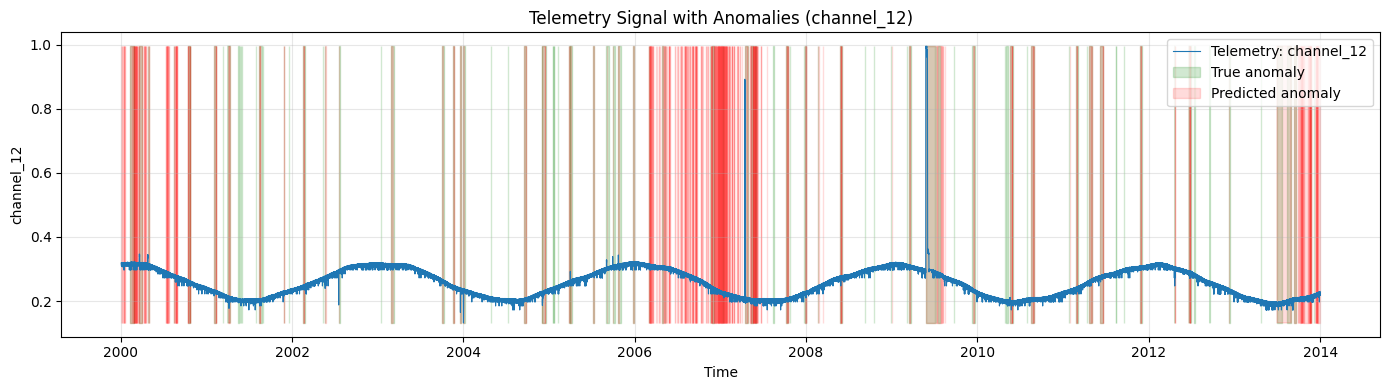

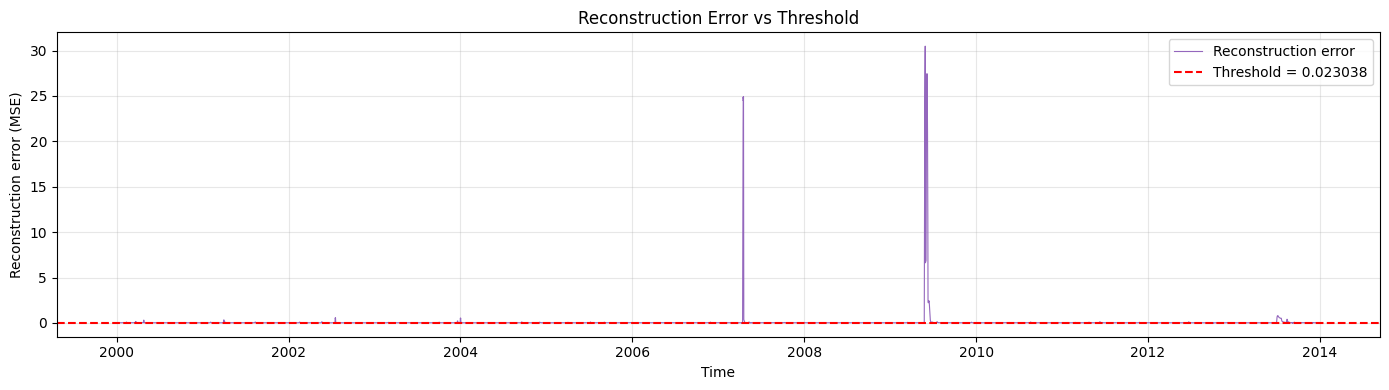

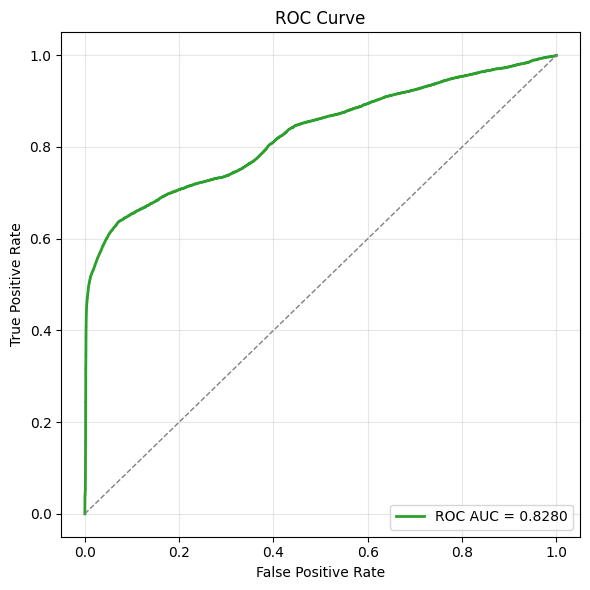

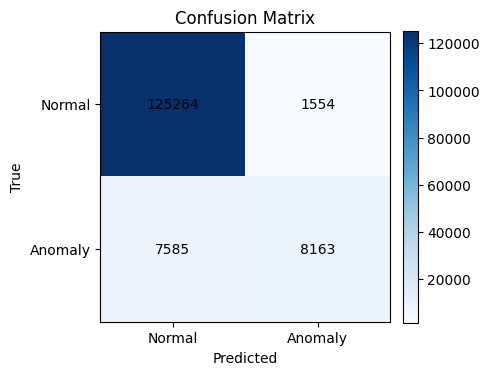

In [31]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, precision_recall_curve, classification_report
)

# Ensure model is in eval mode and compute reconstruction errors
model.eval()
with torch.no_grad():
    reconstructed = model(X_test_tensor)
errors = torch.mean((X_test_tensor - reconstructed) ** 2, dim=1).detach().cpu().numpy()

# Automatically choose threshold by maximizing F1 on PR-curve thresholds
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_test, errors)
if len(thresholds_pr) > 0:
    p = precisions_pr[:-1]
    r = recalls_pr[:-1]
    f1_pr = (2 * p * r) / (p + r + 1e-12)
    threshold = float(thresholds_pr[int(np.argmax(f1_pr))])
else:
    threshold = float(np.median(errors))

# Predictions at selected threshold
y_pred = (errors > threshold).astype(int)

# Metrics
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Optimal threshold (max F1): {threshold:.6f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

# Use exactly one telemetry channel for plotting
channel_for_plot = X.columns[0]
time_index = df.index[window_size:]
signal_series = X.loc[time_index, channel_for_plot].to_numpy()

# 1) Telemetry signal with anomalies (true=green, predicted=red)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_index, signal_series, linewidth=0.8, color="tab:blue", label=f"Telemetry: {channel_for_plot}")
y_min, y_max = signal_series.min(), signal_series.max()
ax.fill_between(time_index, y_min, y_max, where=(y_test == 1),
                color="green", alpha=0.18, label="True anomaly")
ax.fill_between(time_index, y_min, y_max, where=(y_pred == 1),
                color="red", alpha=0.14, label="Predicted anomaly")
ax.set_title(f"Telemetry Signal with Anomalies ({channel_for_plot})")
ax.set_xlabel("Time")
ax.set_ylabel(channel_for_plot)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Reconstruction error vs threshold
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_index, errors, linewidth=0.8, color="tab:purple", label="Reconstruction error")
ax.axhline(threshold, color="red", linestyle="--", linewidth=1.5, label=f"Threshold = {threshold:.6f}")
ax.set_title("Reconstruction Error vs Threshold")
ax.set_xlabel("Time")
ax.set_ylabel("Reconstruction error (MSE)")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) ROC curve
fpr, tpr, _ = roc_curve(y_test, errors)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="tab:green", linewidth=2, label=f"ROC AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Anomaly"])
ax.set_yticklabels(["Normal", "Anomaly"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()